#Select smart cities in India and plot the UTCI trend

In [ ]:
!pip install cdsapi

  Preparing metadata (setup.py) ... done
  Created wheel for multiurl: filename=multiurl-0.3.3-py3-none-any.whl size=21230 sha256=abddda488c5363baf503acccc3e98824cfba3eda3b13bcea1a307e8b2d049ac6
  Stored in directory: /root/.cache/pip/wheels/5a/9e/1e/e307bfc2dddf5adbd8c17f157e42b5ed54a0598a24e54fd202
Successfully built multiurl


In [ ]:
%%writefile /root/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: 9c2b2c3b-baa8-487c-9fb8-ba7e694f73cc

Writing /root/.cdsapirc


In [ ]:
!cat /root/.cdsapirc

url: https://cds.climate.copernicus.eu/api
key: 9c2b2c3b-baa8-487c-9fb8-ba7e694f73cc


# Data Download [1950-2023] for India Bounding Box

In [ ]:
import cdsapi


dataset = "derived-utci-historical"
years = ["2021","2022","2023"]

# Loop
for year in years:
    request = {
        "variable": ["universal_thermal_climate_index"],
        "version": "1_1",
        "product_type": "consolidated_dataset",
        "year": [year],
        "month": [
            "01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"
        ],
        "day": [
            "01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12",
            "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24",
            "25", "26", "27", "28", "29", "30", "31"
        ],
        "area": [37.5, 68.0, 5.0, 97.5],  # Bounding box for India
        "format": "zip"
    }

    # Initialize CDS API client and request data
    client = cdsapi.Client()
    client.retrieve(dataset, request).download(f"daily_utci_india_{year}.zip")


2025-02-03 06:12:22,907 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:datapi.legacy_api_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-02-03 06:12:22,909 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-03 06:12:23,556 INFO Request ID is 151b8fba-ea01-48b1-9b84-477614685d17
INFO:datapi.legacy_api_client:Request ID is 151b8fba-ea01-48b1-9b84-477614685d17
2025-02-03 06:12:23,803 INFO status has been updated to accepted
INFO:datapi.legacy_api_client:status has been updated to accepted
2025-02-03 06:12:29,007 INFO status has been updated to running
INFO:datapi.legacy_api_client:status has been upd

647988c6d537f4b4dadd60cc9de687d0.zip:   0%|          | 0.00/281M [00:00<?, ?B/s]

2025-02-03 06:31:51,375 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:datapi.legacy_api_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-02-03 06:31:51,378 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-03 06:31:51,744 INFO Request ID is 90a6f7a5-f7bb-43f3-aa67-ca3a8da6cc0b
INFO:datapi.legacy_api_client:Request ID is 90a6f7a5-f7bb-43f3-aa67-ca3a8da6cc0b
2025-02-03 06:31:51,896 INFO status has been updated to accepted
INFO:datapi.legacy_api_client:status has been updated to accepted
2025-02-03 06:32:06,198 INFO status has been updated to running
INFO:datapi.legacy_api_client:status has been upd

e845cdf0cbe44b644d59ac0cc1a01e0b.zip:   0%|          | 0.00/281M [00:00<?, ?B/s]

2025-02-03 06:45:03,614 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:datapi.legacy_api_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-02-03 06:45:03,617 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-02-03 06:45:04,241 INFO Request ID is a1f928ab-e06d-441a-93f2-cd7322c8531e
INFO:datapi.legacy_api_client:Request ID is a1f928ab-e06d-441a-93f2-cd7322c8531e
2025-02-03 06:45:04,432 INFO status has been updated to accepted
INFO:datapi.legacy_api_client:status has been updated to accepted
2025-02-03 06:45:13,149 INFO status has been updated to running
INFO:datapi.legacy_api_client:status has been upd

939b8de97d5b8cd473504f90a780b6be.zip:   0%|          | 0.00/280M [00:00<?, ?B/s]

#Unzipping and extracting the downloaded files

In [ ]:
import os
import zipfile
import xarray as xr

# directories
data_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/Raw zip file 1950-2023 (India bounding region)'
extracted_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/Extracted files'

# directory for extracted files
os.makedirs(extracted_dir, exist_ok=True)

# Unzipping
for year in range(1991, 2024):
    zip_path = os.path.join(data_dir, f'{year}.zip')
    year_dir = os.path.join(extracted_dir, str(year))
    os.makedirs(year_dir, exist_ok=True)


    if not os.listdir(year_dir):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(year_dir)
        print(f'Extracted: {year}')
    else:
        print(f'Already extracted: {year}')




Extracted: 1991
Extracted: 1992
Extracted: 1993
Extracted: 1994
Extracted: 1995
Extracted: 1996
Extracted: 1997
Extracted: 1998
Extracted: 1999
Extracted: 2000
Extracted: 2001
Extracted: 2002
Extracted: 2003
Extracted: 2004
Extracted: 2005
Extracted: 2006
Extracted: 2007
Extracted: 2008
Extracted: 2009
Extracted: 2010
Extracted: 2011
Extracted: 2012
Extracted: 2013
Extracted: 2014
Extracted: 2015
Extracted: 2016
Extracted: 2017
Extracted: 2018
Extracted: 2019
Extracted: 2020
Extracted: 2021
Extracted: 2022
Extracted: 2023


# Monthly average UTCI for each year and then combine these averages across all years

In [ ]:
import xarray as xr
import pandas as pd
import os


base_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/Extracted files'
years = range(1991, 2024)

# List to hold monthly averages
monthly_avg_list = []

# Processing the data
for year in years:
    year_folder = os.path.join(base_dir, str(year))
    yearly_data = []

    # Load all .nc files in the folder
    #Dask for efficient memory handling
    for file_name in os.listdir(year_folder):
        if file_name.endswith('.nc'):
            file_path = os.path.join(year_folder, file_name)
            data = xr.open_dataset(file_path, chunks={'time': 30})
            yearly_data.append(data)

    # Concatenate
    if yearly_data:
        year_dataset = xr.concat(yearly_data, dim='time')

        # Calculate monthly average
        monthly_avg = year_dataset['utci'].resample(time='1ME').mean()
        monthly_avg_list.append(monthly_avg)

# Concatenate
final_monthly_avg_new = xr.concat(monthly_avg_list, dim='time')

print(final_monthly_avg_new)


<xarray.DataArray 'utci' (time: 396, lat: 131, lon: 119)> Size: 25MB
dask.array<concatenate, shape=(396, 131, 119), dtype=float32, chunksize=(1, 131, 119), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * time     (time) datetime64[ns] 3kB 1991-01-31 1991-02-28 ... 2023-12-31
Attributes:
    code:     167
    table:    128


In [ ]:
final_monthly_avg_new


<xarray.DataArray 'utci' (time: 396, lat: 131, lon: 119)> Size: 25MB
dask.array<concatenate, shape=(396, 131, 119), dtype=float32, chunksize=(1, 131, 119), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * time     (time) datetime64[ns] 3kB 1991-01-31 1991-02-28 ... 2023-12-31
Attributes:
    code:     167
    table:    128

In [ ]:
# to net cdf file format
final_monthly_avg_new.to_netcdf('monthly_avg(1991-2023).nc')

**Combine the .nc file**

In [ ]:
import xarray as xr
import pandas as pd
import os


file_path1 = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/compiled file/monthly_avg(1950-1990).nc'
file_path2 = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/compiled file/monthly_avg(1991-2023).nc'

# Load
data1 = xr.open_dataset(file_path1)
data2 = xr.open_dataset(file_path2)

# Concatenate
combined_data = xr.concat([data1, data2], dim='time')


print(combined_data)


combined_data.to_netcdf('/content/drive/MyDrive/Work @Weclimb/Smart cities work/compiled file/monthly_avg(1950-2023).nc')


<xarray.Dataset> Size: 55MB
Dimensions:  (time: 888, lat: 131, lon: 119)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-31 1950-02-28 ... 2023-12-31
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
Data variables:
    utci     (time, lat, lon) float32 55MB 269.5 271.0 271.6 ... 299.2 301.5


In [ ]:
print (combined_data)

<xarray.Dataset> Size: 55MB
Dimensions:  (time: 888, lat: 131, lon: 119)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-31 1950-02-28 ... 2023-12-31
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
Data variables:
    utci     (time, lat, lon) float32 55MB 269.5 271.0 271.6 ... 299.2 301.5


In [ ]:
# to DataFrame
df = combined_data.to_dataframe().reset_index()

print(df.head())


        time   lat    lon        utci
0 1950-01-31  37.5  68.00  269.546753
1 1950-01-31  37.5  68.25  270.966064
2 1950-01-31  37.5  68.50  271.562897
3 1950-01-31  37.5  68.75  270.946625
4 1950-01-31  37.5  69.00  269.218262


#smart cities India

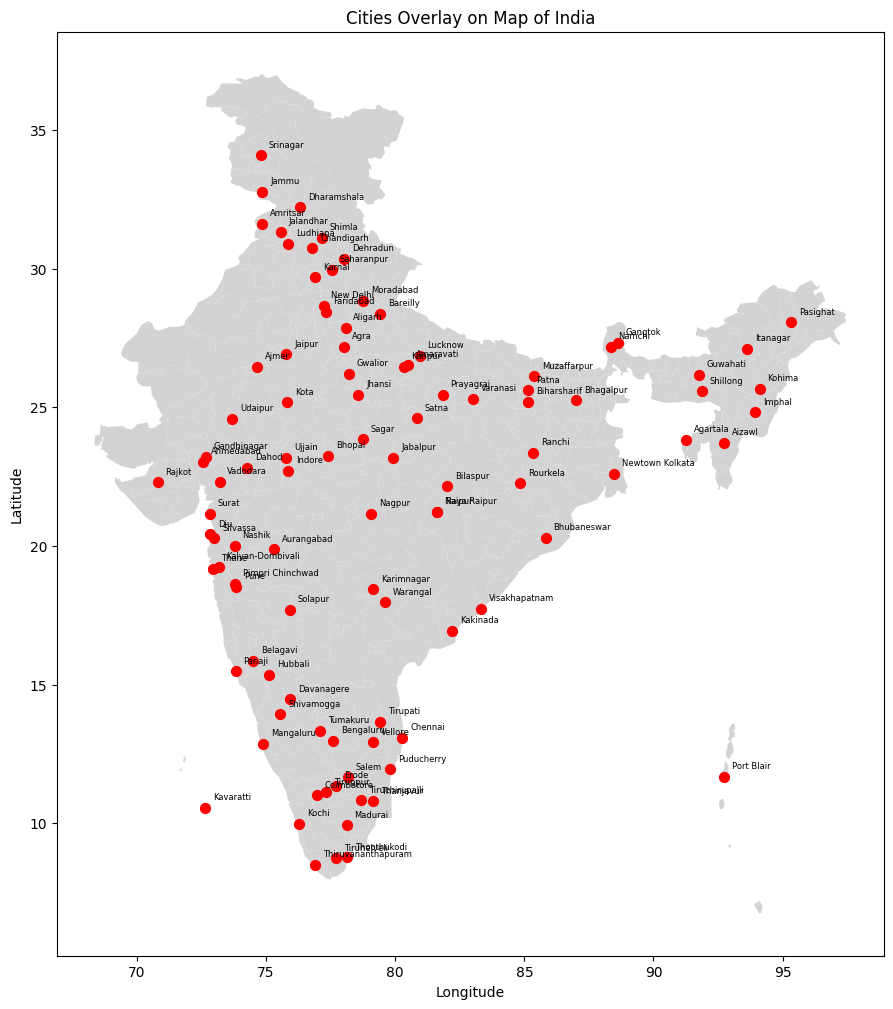

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load the shapefile
india_map = gpd.read_file('/content/drive/MyDrive/Work @Weclimb/Smart cities work/India Shape/india_ds.shp')

# Load city data from Excel
excel_file = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/smart cities list/grids.xlsx'  # Replace with your file path
cities_df = pd.read_excel(excel_file)

# Ensure the Excel file has columns: 'City', 'Longitude', 'Latitude'

# Convert to GeoDataFrame
cities_gdf = gpd.GeoDataFrame(
    cities_df,
    geometry=gpd.points_from_xy(cities_df['Longitude'], cities_df['Latitude']),
    crs='EPSG:4326'
)

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))
india_map.plot(ax=ax, color='lightgray')
cities_gdf.plot(ax=ax, color='red', markersize=50)

# Add city labels
for x, y, label in zip(cities_gdf.geometry.x, cities_gdf.geometry.y, cities_gdf['City']):
    ax.text(x + 0.3, y + 0.3, label, fontsize=6)

plt.title('Cities Overlay on Map of India')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


**Load the smart cities list**

In [ ]:

smart_cities = pd.read_excel('/content/drive/MyDrive/Work @Weclimb/Smart cities work/smart cities list/grids.xlsx')


In [ ]:
#Picking or sorting smart cities india from the whole india bounding region using nearest matching approach
city_utci_data = []

for index, city in smart_cities.iterrows():
    city_name = city['City']
    lon = city['Longitude']
    lat = city['Latitude']

    # (nearest matching)
    utci_city = combined_data['utci'].sel(lon=lon, lat=lat, method='nearest')

    # Convert to DataFrame
    city_data = utci_city.to_dataframe().reset_index()
    city_data['City'] = city_name

    city_utci_data.append(city_data)

# Combine
final_city_utci = pd.concat(city_utci_data, ignore_index=True)

print(final_city_utci.head(880000))

            time    lat    lon        utci         City
0     1950-01-31  20.25  85.75  294.622894  Bhubaneswar
1     1950-02-28  20.25  85.75  296.236481  Bhubaneswar
2     1950-03-31  20.25  85.75  299.911224  Bhubaneswar
3     1950-04-30  20.25  85.75  304.812408  Bhubaneswar
4     1950-05-31  20.25  85.75  306.605438  Bhubaneswar
...          ...    ...    ...         ...          ...
88795 2023-08-31  25.50  92.00  296.490173     Shillong
88796 2023-09-30  25.50  92.00  297.827393     Shillong
88797 2023-10-31  25.50  92.00  293.832062     Shillong
88798 2023-11-30  25.50  92.00  290.642029     Shillong
88799 2023-12-31  25.50  92.00  287.863922     Shillong

[88800 rows x 5 columns]


In [ ]:
# Kelvin to Celsius
final_city_utci['utci_celsius'] = final_city_utci['utci'] - 273.15

# Display
print(final_city_utci.head())


        time    lat    lon        utci         City  utci_celsius
0 1950-01-31  20.25  85.75  294.622894  Bhubaneswar     21.472900
1 1950-02-28  20.25  85.75  296.236481  Bhubaneswar     23.086487
2 1950-03-31  20.25  85.75  299.911224  Bhubaneswar     26.761230
3 1950-04-30  20.25  85.75  304.812408  Bhubaneswar     31.662415
4 1950-05-31  20.25  85.75  306.605438  Bhubaneswar     33.455444


In [ ]:
#Saving the file as excel format
final_city_utci.to_excel('utci_data_smart cities (1950-2023).xlsx', index=True)

#Plotting the annual cycle

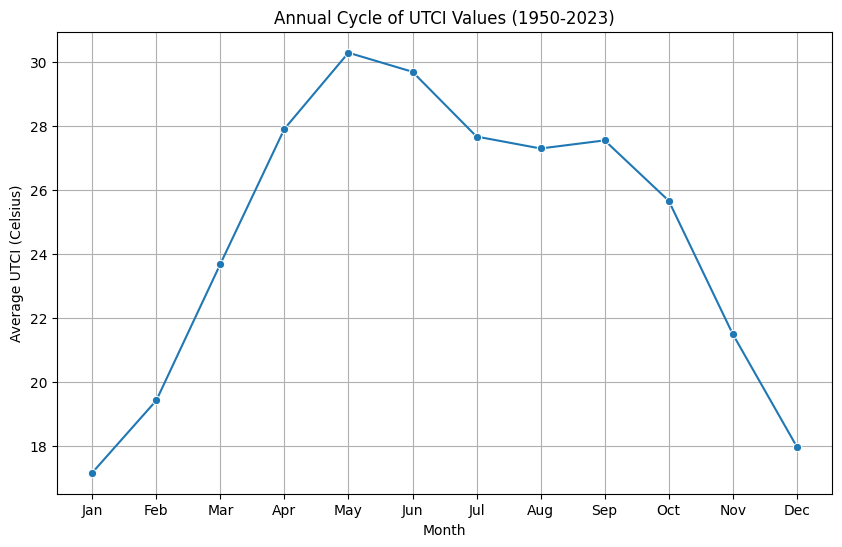

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


final_city_utci['time'] = pd.to_datetime(final_city_utci['time'])

# Extract month
final_city_utci['month'] = final_city_utci['time'].dt.month

# Calculate the average UTCI for each month across all years and cities
monthly_avg_utci = final_city_utci.groupby('month')['utci_celsius'].mean().reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='utci_celsius', data=monthly_avg_utci, marker='o')
plt.title('Annual Cycle of UTCI Values (1950-2023)')
plt.xlabel('Month')
plt.ylabel('Average UTCI (Celsius)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

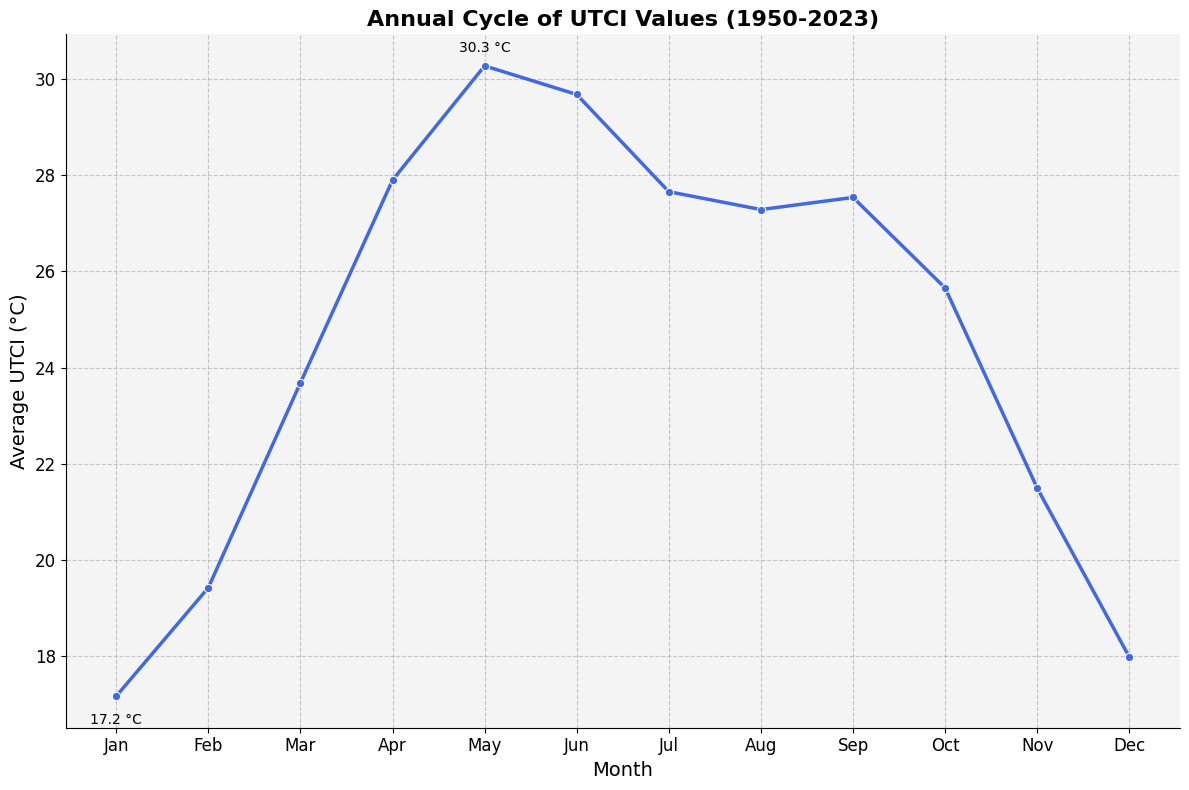

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


final_city_utci['time'] = pd.to_datetime(final_city_utci['time'])
final_city_utci['month'] = final_city_utci['time'].dt.month

# Calculate the average UTCI
monthly_avg_utci = final_city_utci.groupby('month')['utci_celsius'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 8))
sns.lineplot(x='month', y='utci_celsius', data=monthly_avg_utci, marker='o',
             linewidth=2.5, color='royalblue')


plt.title('Annual Cycle of UTCI Values (1950-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average UTCI (°C)', fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
           fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


plt.gca().set_facecolor('#f4f4f4')


sns.despine()

# min/max values
min_utci = monthly_avg_utci['utci_celsius'].min()
max_utci = monthly_avg_utci['utci_celsius'].max()
min_month = monthly_avg_utci.loc[monthly_avg_utci['utci_celsius'].idxmin(), 'month']
max_month = monthly_avg_utci.loc[monthly_avg_utci['utci_celsius'].idxmax(), 'month']

plt.annotate(f'{min_utci:.1f} °C', (min_month, min_utci), textcoords="offset points", xytext=(0, -20), ha='center')
plt.annotate(f'{max_utci:.1f} °C', (max_month, max_utci), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

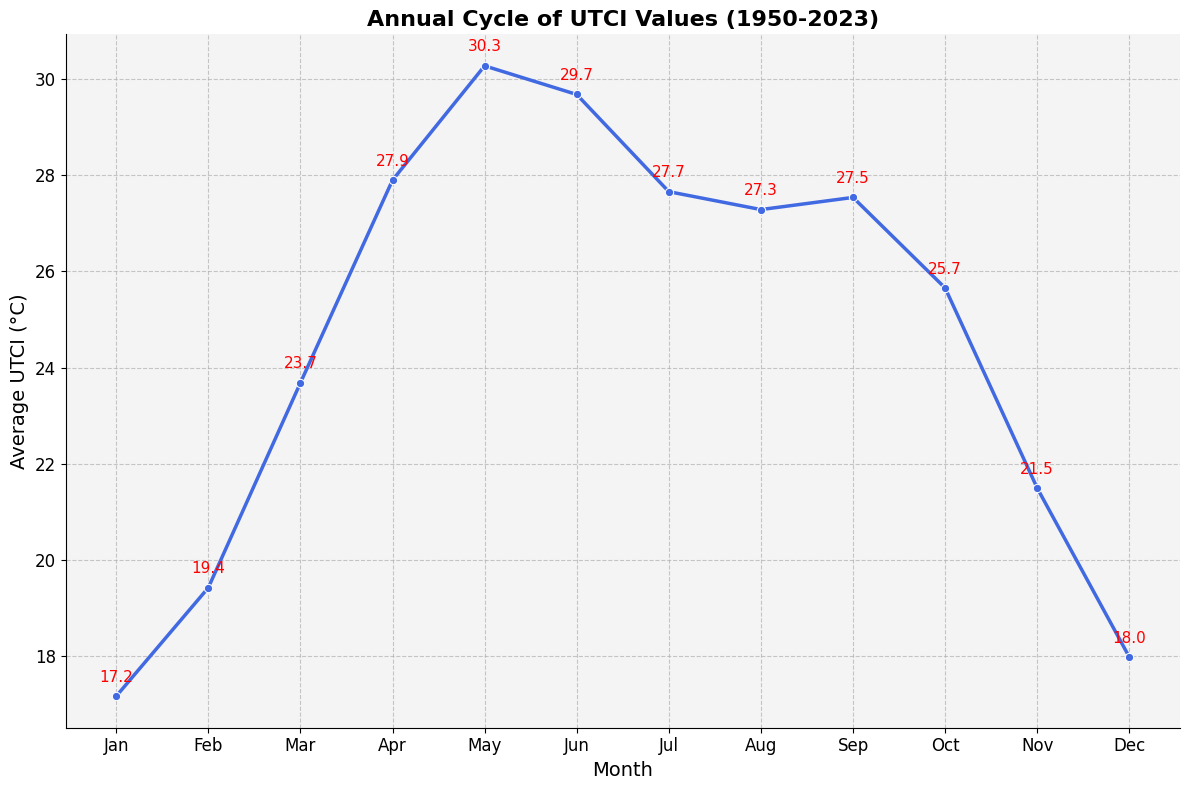

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


final_city_utci['time'] = pd.to_datetime(final_city_utci['time'])
final_city_utci['month'] = final_city_utci['time'].dt.month

# Calculate the average UTCI
monthly_avg_utci = final_city_utci.groupby('month')['utci_celsius'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 8))
sns.lineplot(x='month', y='utci_celsius', data=monthly_avg_utci, marker='o',
             linewidth=2.5, color='royalblue')


plt.title('Annual Cycle of UTCI Values (1950-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average UTCI (°C)', fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f4f4f4')
sns.despine()

# Add value labels to each data point
for index, row in monthly_avg_utci.iterrows():
    plt.text(row['month'], row['utci_celsius'] + 0.3,
             f'{row["utci_celsius"]:.1f}',
             ha='center', fontsize=11, color='red')

# Add annotations for min/max values
min_utci = monthly_avg_utci['utci_celsius'].min()
max_utci = monthly_avg_utci['utci_celsius'].max()
min_month = monthly_avg_utci.loc[monthly_avg_utci['utci_celsius'].idxmin(), 'month']
max_month = monthly_avg_utci.loc[monthly_avg_utci['utci_celsius'].idxmax(), 'month']

#plt.annotate(f'{min_utci:.1f} °C', (min_month, min_utci),
             #textcoords="offset points", xytext=(0, -20), ha='center', fontsize=11, fontweight='bold')
#plt.annotate(f'{max_utci:.1f} °C', (max_month, max_utci),
             #textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
import nbformat

filename = "/content/WeClimp_smart_cities_and_UTCI_Trend (1).ipynb"

with open(filename, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Remove corrupt 'widgets' metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

with open(filename, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("✅ Notebook metadata cleaned. Re-upload to GitHub.")


✅ Notebook metadata cleaned. Re-upload to GitHub.


#Days by heat stress levels


| Heat Stress Category    | UTCI (°C) Range |
| ----------------------- | --------------- |
| Strong Heat Stress      | >32°C to 38°C   |
| Very Strong Heat Stress | >38°C to 46°C   |
| Extreme Heat Stress     | >46°C           |


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import seaborn as sns

# Load data
df = pd.read_excel('/content/utci_data_smart cities (1950-2023).xlsx', parse_dates=['time'])

# Extract year and decade
df['year'] = df['time'].dt.year
df['decade'] = (df['year'] // 10) * 10

# Define UTCI Heat Stress Categories
df['Strong'] = ((df['utci_celsius'] > 32) & (df['utci_celsius'] <= 38)).astype(int)
df['VeryStrong'] = ((df['utci_celsius'] > 38) & (df['utci_celsius'] <= 46)).astype(int)
df['Extreme'] = (df['utci_celsius'] > 46).astype(int)

# Aggregate: Count stress days per year per city
yearly = df.groupby(['City', 'year'])[['Strong', 'VeryStrong', 'Extreme']].sum().reset_index()




/tmp/ipython-input-14-1167696613.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_counts = df_heat.groupby(['Year', 'HeatStress']).size().unstack(fill_value=0)


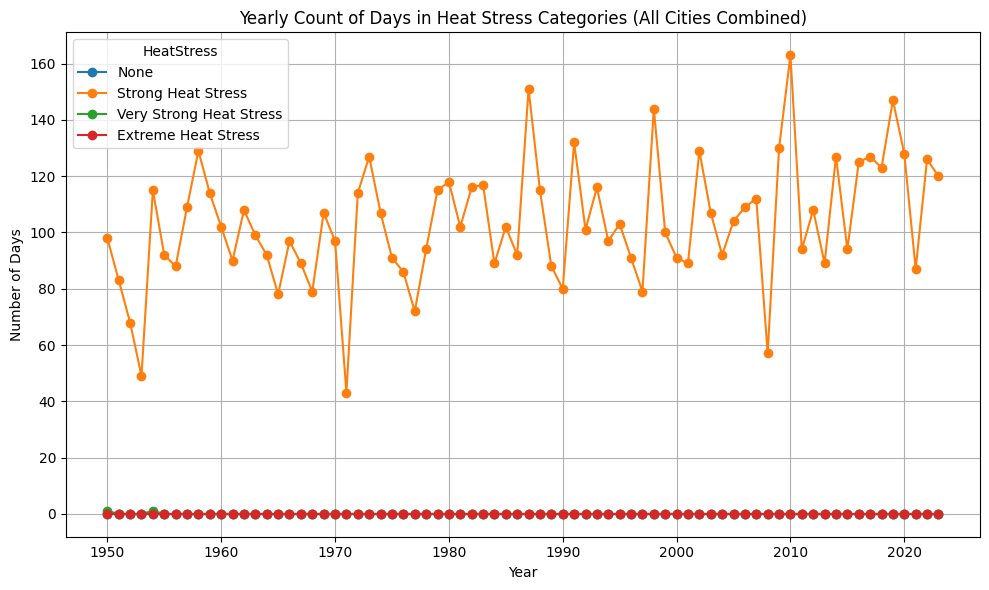

/tmp/ipython-input-14-1167696613.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decade_counts = df_heat.groupby(['Decade', 'HeatStress']).size().unstack(fill_value=0)


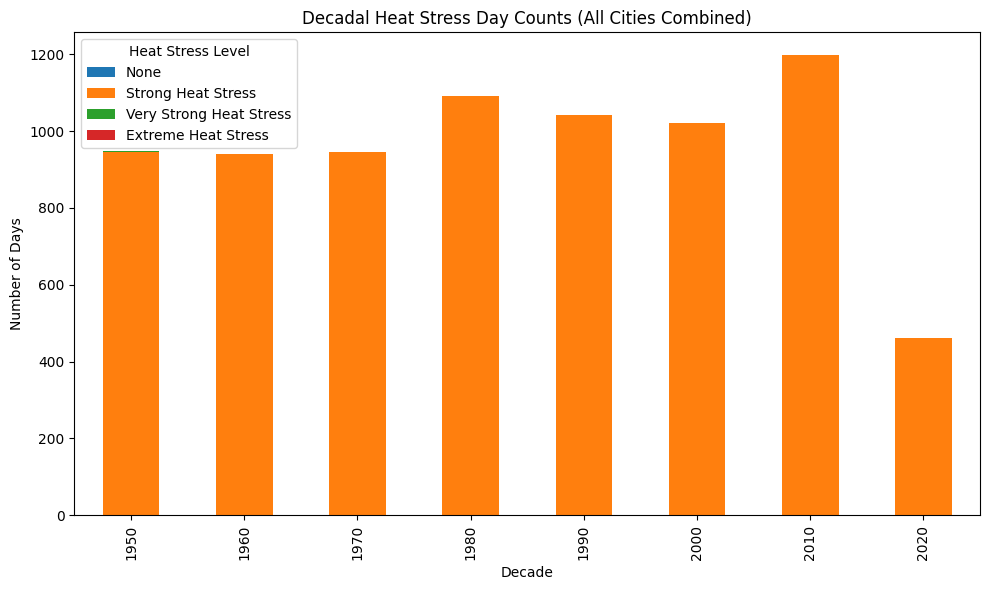

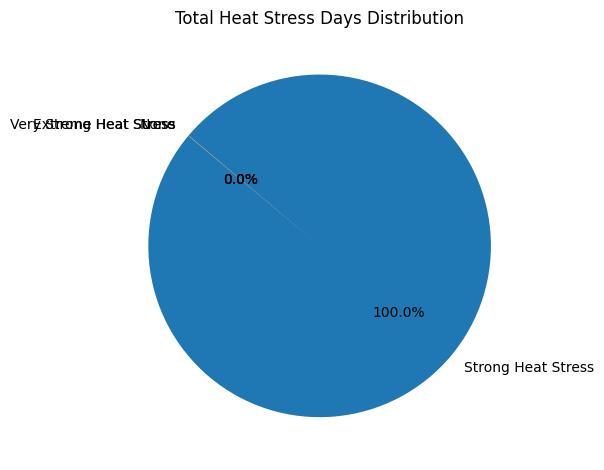

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file (update path if needed)
excel_path = "/content/utci_data_smart cities (1950-2023).xlsx"
df = pd.read_excel(excel_path)

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract year and decade
df['Year'] = df['time'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

# Rename 'utci_celsius' to 'UTCI' for clarity in plotting
df = df.rename(columns={'utci_celsius': 'UTCI'})


# Classify stress levels
conditions = [
    df['UTCI'] > 46,
    (df['UTCI'] > 38) & (df['UTCI'] <= 46),
    (df['UTCI'] > 32) & (df['UTCI'] <= 38)
]
choices = ['Extreme Heat Stress', 'Very Strong Heat Stress', 'Strong Heat Stress']
df['HeatStress'] = pd.cut(df['UTCI'], bins=[-float('inf'), 32, 38, 46, float('inf')],
                                labels=['None', 'Strong Heat Stress', 'Very Strong Heat Stress', 'Extreme Heat Stress'])

# Filter out 'None'
df_heat = df[df['HeatStress'] != 'None'].copy()

# --- A. Time series plot (yearly count for each heat stress category) ---
yearly_counts = df_heat.groupby(['Year', 'HeatStress']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
yearly_counts.plot(marker='o', ax=plt.gca())
plt.title('Yearly Count of Days in Heat Stress Categories (All Cities Combined)')
plt.ylabel('Number of Days')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- B. Bar chart (total per decade) ---
decade_counts = df_heat.groupby(['Decade', 'HeatStress']).size().unstack(fill_value=0)

decade_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Decadal Heat Stress Day Counts (All Cities Combined)')
plt.ylabel('Number of Days')
plt.xlabel('Decade')
plt.legend(title='Heat Stress Level')
plt.tight_layout()
plt.show()

# --- C. Pie chart (total days across all years) ---
total_counts = df_heat['HeatStress'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(total_counts, labels=total_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Total Heat Stress Days Distribution')
plt.tight_layout()
plt.show()

#The verification from Daily Dataset

In [ ]:
import xarray as xr
import os

# Input folder (contains subfolders like 1991, 1992, ...)
input_base_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/Extracted files'

# Output folder for saving daily average NetCDFs
output_base_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets'
os.makedirs(output_base_dir, exist_ok=True)

years = range(1980, 2010)

for year in years:
    print(f"🔄 Processing year {year}...")
    year_folder = os.path.join(input_base_dir, str(year))
    output_file = os.path.join(output_base_dir, f"utci_daily_avg_{year}.nc")

    yearly_data = []

    # Check if year folder exists
    if not os.path.isdir(year_folder):
        print(f"❌ Folder not found: {year_folder}")
        continue

    # Load and process .nc files
    for file_name in os.listdir(year_folder):
        if file_name.endswith('.nc'):
            file_path = os.path.join(year_folder, file_name)
            try:
                data = xr.open_dataset(file_path, chunks={'time': 30})  # dask-friendly
                yearly_data.append(data)
            except Exception as e:
                print(f"⚠️ Error reading {file_path}: {e}")

    if yearly_data:
        try:
            # Concatenate along time axis
            year_dataset = xr.concat(yearly_data, dim='time')

            # Compute daily average
            daily_avg = year_dataset['utci'].resample(time='1D').mean()

            # Save to new NetCDF file
            daily_avg.to_netcdf(output_file)
            print(f"✅ Saved daily average to {output_file}")

        except Exception as e:
            print(f"❌ Failed to process year {year}: {e}")
    else:
        print(f"⚠️ No data files found for {year}")


🔄 Processing year 1980...
✅ Saved daily average to /content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1980.nc
🔄 Processing year 1981...
✅ Saved daily average to /content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1981.nc
🔄 Processing year 1982...
✅ Saved daily average to /content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1982.nc
🔄 Processing year 1983...
✅ Saved daily average to /content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1983.nc
🔄 Processing year 1984...
✅ Saved daily average to /content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1984.nc
🔄 Processing year 1985...
✅ Saved daily average to /content/drive/MyDrive/Work @

<xarray.Dataset> Size: 23MB
Dimensions:  (time: 365, lat: 131, lon: 119)
Coordinates:
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * time     (time) datetime64[ns] 3kB 1950-01-01 1950-01-02 ... 1950-12-31
Data variables:
    utci     (time, lat, lon) float32 23MB ...
Data variables:
    utci     (time, lat, lon) float32 23MB ...
Coordinates:
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * lat      (lat) float64 1kB 37.5 37.25 37.0 36.75 36.5 ... 5.75 5.5 5.25 5.0
  * time     (time) datetime64[ns] 3kB 1950-01-01 1950-01-02 ... 1950-12-31


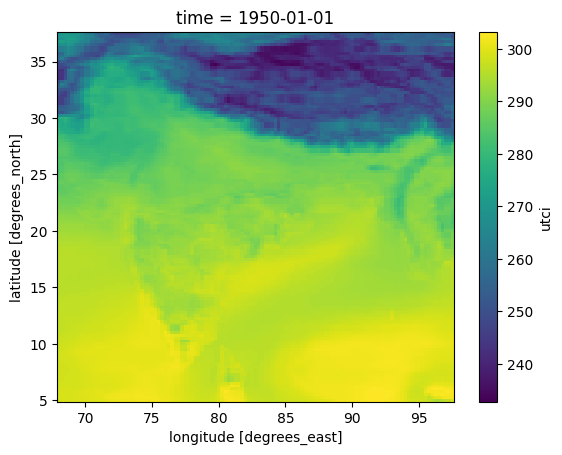

In [ ]:
#to check
import xarray as xr

# Load NetCDF file
ds = xr.open_dataset('/content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1950.nc')


print(ds)
print(ds.data_vars)
print(ds.coords)
print(ds.dims)
print(ds.attrs)
ds['utci'].isel(time=0).plot()


In [ ]:
#verifying the daily averaged .nc file
import xarray as xr

# Path to one of your daily-average files
file_path = ('/content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets/utci_daily_avg_1950.nc')


# Open the dataset
ds = xr.open_dataset(file_path)

# Check the time dimension
print(ds['time'])
print(f"Number of time steps: {ds['time'].size}")


<xarray.DataArray 'time' (time: 365)> Size: 3kB
array(['1950-01-01T00:00:00.000000000', '1950-01-02T00:00:00.000000000',
       '1950-01-03T00:00:00.000000000', ..., '1950-12-29T00:00:00.000000000',
       '1950-12-30T00:00:00.000000000', '1950-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1950-01-01 1950-01-02 ... 1950-12-31
Attributes:
    standard_name:  time
    axis:           T
Number of time steps: 365


In [ ]:
#verifying the hourly dataset .nc file
import xarray as xr

# Path to one of your daily-average files
file_path = ('/content/drive/MyDrive/Work @Weclimb/Smart cities work/Extracted files/1950/ECMWF_utci_19500101_v1.1_con.area-subset.37.5.68.0.5.0.97.5.nc')


# Open the dataset
ds = xr.open_dataset(file_path)

# Check the time dimension
print(ds['time'])
print(f"Number of time steps: {ds['time'].size}")

<xarray.DataArray 'time' (time: 24)> Size: 192B
array(['1950-01-01T00:00:00.000000000', '1950-01-01T01:00:00.000000000',
       '1950-01-01T02:00:00.000000000', '1950-01-01T03:00:00.000000000',
       '1950-01-01T04:00:00.000000000', '1950-01-01T05:00:00.000000000',
       '1950-01-01T06:00:00.000000000', '1950-01-01T07:00:00.000000000',
       '1950-01-01T08:00:00.000000000', '1950-01-01T09:00:00.000000000',
       '1950-01-01T10:00:00.000000000', '1950-01-01T11:00:00.000000000',
       '1950-01-01T12:00:00.000000000', '1950-01-01T13:00:00.000000000',
       '1950-01-01T14:00:00.000000000', '1950-01-01T15:00:00.000000000',
       '1950-01-01T16:00:00.000000000', '1950-01-01T17:00:00.000000000',
       '1950-01-01T18:00:00.000000000', '1950-01-01T19:00:00.000000000',
       '1950-01-01T20:00:00.000000000', '1950-01-01T21:00:00.000000000',
       '1950-01-01T22:00:00.000000000', '1950-01-01T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[n

#Combine .nc file


In [ ]:
import xarray as xr
import os

# Folder containing your .nc files
folder_path = "/content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset/Daily average datasets"

# List all .nc files
nc_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.nc')]
nc_files.sort()  # optional: sort by filename

# Open and combine all files along the time dimension (assuming they have the same variables & dimensions)
ds_combined = xr.open_mfdataset(nc_files, combine='by_coords')

# Save to a single NetCDF file
ds_combined.to_netcdf("combined.nc")


In [ ]:
import xarray as xr
import pandas as pd

# Open NetCDF lazily using dask
ds = xr.open_dataset("/content/combined.nc", chunks={'time': 30})  # chunk by 30 time steps
var_name = 'utci'  # your variable


In [ ]:
import pandas as pd

cities = pd.read_excel("/content/drive/MyDrive/Work @Weclimb/Smart cities work/smart cities list/grids.xlsx")

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np

# Open dataset lazily
ds = xr.open_dataset("/content/combined.nc", chunks={'time': 30})  # adjust chunk size if needed
var_name = 'utci'  # variable name in your NetCDF

csv_file = "smart_cities_utci.csv"
header_written = False

for t_start in range(0, ds.dims['time'], 30):
    t_end = min(t_start + 30, ds.dims['time'])
    ds_chunk = ds.isel(time=slice(t_start, t_end))

    # List to hold data for this chunk
    chunk_data = []

    for _, city in cities.iterrows():
        # Find nearest grid point
        utci_values = ds_chunk[var_name].sel(
            lat=city['Latitude'], lon=city['Longitude'], method='nearest'
        ).to_dataframe().reset_index()

        utci_values['City'] = city['City']
        chunk_data.append(utci_values)

    # Combine all cities for this chunk
    df_chunk = pd.concat(chunk_data, ignore_index=True)

    # Append to CSV
    df_chunk.to_csv(csv_file, mode='a', index=False, header=not header_written)
    header_written = True

    print(f"Time steps {t_start}-{t_end} processed")


/tmp/ipython-input-538293462.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t_start in range(0, ds.dims['time'], 30):
/tmp/ipython-input-538293462.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_end = min(t_start + 30, ds.dims['time'])


Time steps 0-30 processed


/tmp/ipython-input-538293462.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_end = min(t_start + 30, ds.dims['time'])


Time steps 30-60 processed


/tmp/ipython-input-538293462.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_end = min(t_start + 30, ds.dims['time'])


...

Time steps 26940-26970 processed


/tmp/ipython-input-538293462.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_end = min(t_start + 30, ds.dims['time'])


Time steps 26970-27000 processed


/tmp/ipython-input-538293462.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  t_end = min(t_start + 30, ds.dims['time'])


Time steps 27000-27028 processed


#Categorisation and smart cities list

In [ ]:
import os
import xarray as xr
import pandas as pd


base_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/Extracted files'  # Change if needed
city_file = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/smart cities list/grids.xlsx'  # Your Excel file
output_dir = '/content/drive/MyDrive/Work @Weclimb/Smart cities work/verification with daily dataset'  # Where results will go
years = range(1950, 2024)

In [ ]:
# Load smart cities list
smart_cities = pd.read_excel(city_file)

# Optional: Rename columns if needed
smart_cities.rename(columns={
    'city_name': 'City',
    'lat': 'Latitude',
    'lon': 'Longitude'
}, inplace=True)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/smart_cities_utci.csv")  # or .csv if you used CSV

In [ ]:
df

,time,lon,lat,utci,City
0,1950-01-01,85.75,20.25,293.97586,Bhubaneswar
1,1950-01-02,85.75,20.25,296.20593,Bhubaneswar
2,1950-01-03,85.75,20.25,295.80185,Bhubaneswar
3,1950-01-04,85.75,20.25,292.81204,Bhubaneswar
4,1950-01-05,85.75,20.25,290.50200,Bhubaneswar
...,...,...,...,...,...
2702795,2023-12-27,92.00,25.50,287.32025,Shillong
2702796,2023-12-28,92.00,25.50,286.90840,Shillong
2702797,2023-12-29,92.00,25.50,287.36337,Shillong
2702798,2023-12-30,92.00,25.50,287.90420,Shillong


In [ ]:
def classify_utci_extended(val):
    if val > 46:
        return "Extreme heat stress", "Supplement liquids (>0.50 L/hr), use an air conditioner or remain in shaded area, and undertake no physical activity"
    elif val > 38:
        return "Very strong heat stress", "Supplement liquids (>0.50 L/hr), temporarily use an air conditioner or remain in a shaded area, and limit physical activity"
    elif val > 32:
        return "Strong heat stress", "Supplement liquids (>0.25 L/hr), reduce physical activity, and temporarily use an air conditioner or remain in a shaded area"
    elif val > 26:
        return "Moderate heat stress", "Supplement liquids (>0.25 L/hr)"
    elif val > 9:
        return "No thermal stress", "None"
    elif val > 0:
        return "Slight cold stress", "Use of gloves and a hat"
    elif val > -13:
        return "Moderate cold stress", "Intensify physical activity and protect extremities and face from cold"
    elif val > -27:
        return "Strong cold stress", "Intensify physical activity, protect extremities and face from cold, and use warmer clothing"
    elif val > -40:
        return "Very strong cold stress", "Intensify physical activity, protect extremities and face from cold, use warmer clothing, and limit time spent outdoors"
    else:
        return "Extreme cold stress", "Stay indoors; if outdoor exposure is necessary, use heavy and wind-protected clothing"




In [ ]:
df['utci_celsius'] = df['utci'] - 273.15


In [ ]:
df

,time,lon,lat,utci,City,utci_celsius
0,1950-01-01,85.75,20.25,293.97586,Bhubaneswar,20.82586
1,1950-01-02,85.75,20.25,296.20593,Bhubaneswar,23.05593
2,1950-01-03,85.75,20.25,295.80185,Bhubaneswar,22.65185
3,1950-01-04,85.75,20.25,292.81204,Bhubaneswar,19.66204
4,1950-01-05,85.75,20.25,290.50200,Bhubaneswar,17.35200
...,...,...,...,...,...,...
2702795,2023-12-27,92.00,25.50,287.32025,Shillong,14.17025
2702796,2023-12-28,92.00,25.50,286.90840,Shillong,13.75840
2702797,2023-12-29,92.00,25.50,287.36337,Shillong,14.21337
2702798,2023-12-30,92.00,25.50,287.90420,Shillong,14.75420


In [ ]:
# Apply classification function to each UTCI value
df[['UTCI Category', 'Recommended Action']] = df['utci_celsius'].apply(
    lambda val: pd.Series(classify_utci_extended(val))
)


In [ ]:
df

,time,lon,lat,utci,City,utci_celsius,UTCI Category,Recommended Action
0,1950-01-01,85.75,20.25,293.97586,Bhubaneswar,20.82586,No thermal stress,None
1,1950-01-02,85.75,20.25,296.20593,Bhubaneswar,23.05593,No thermal stress,None
2,1950-01-03,85.75,20.25,295.80185,Bhubaneswar,22.65185,No thermal stress,None
3,1950-01-04,85.75,20.25,292.81204,Bhubaneswar,19.66204,No thermal stress,None
4,1950-01-05,85.75,20.25,290.50200,Bhubaneswar,17.35200,No thermal stress,None
...,...,...,...,...,...,...,...,...
2702795,2023-12-27,92.00,25.50,287.32025,Shillong,14.17025,No thermal stress,None
2702796,2023-12-28,92.00,25.50,286.90840,Shillong,13.75840,No thermal stress,None
2702797,2023-12-29,92.00,25.50,287.36337,Shillong,14.21337,No thermal stress,None
2702798,2023-12-30,92.00,25.50,287.90420,Shillong,14.75420,No thermal stress,None


#visualization

Annual cycle of UTCI

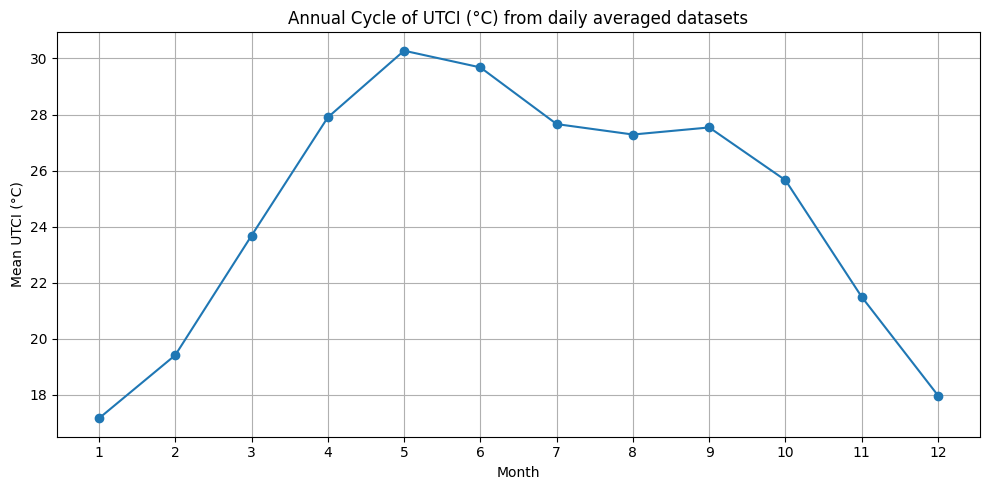

In [ ]:
import matplotlib.pyplot as plt

# Convert time column to datetime (if not already)
df['time'] = pd.to_datetime(df['time'])

# Extract month
df['month'] = df['time'].dt.month

# Group by month and take average UTCI (in Celsius)
monthly_cycle = df.groupby('month')['utci_celsius'].mean()

# Plot
plt.figure(figsize=(10, 5))
monthly_cycle.plot(marker='o')
plt.title("Annual Cycle of UTCI (°C) from daily averaged datasets")
plt.xlabel("Month")
plt.ylabel("Mean UTCI (°C)")
plt.grid(True)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

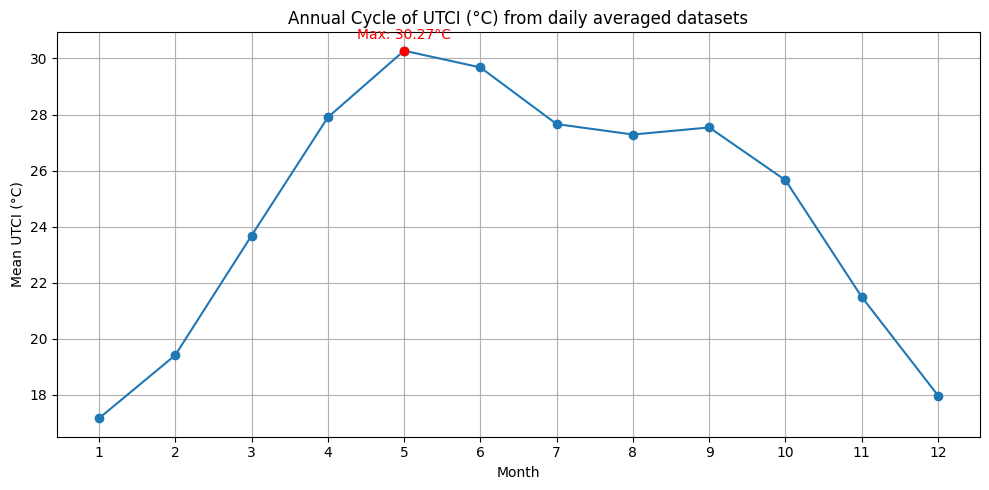

In [ ]:
import matplotlib.pyplot as plt

# Find max value and its corresponding month
max_month = monthly_cycle.idxmax()
max_value = monthly_cycle.max()

plt.figure(figsize=(10, 5))
monthly_cycle.plot(marker='o')

# Highlight max point
plt.plot(max_month, max_value, 'ro')  # red dot
plt.text(max_month, max_value + 0.3, f"Max: {max_value:.2f}°C",
         ha='center', va='bottom', fontsize=10, color='red')

plt.title("Annual Cycle of UTCI (°C) from daily averaged datasets")
plt.xlabel("Month")
plt.ylabel("Mean UTCI (°C)")
plt.grid(True)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


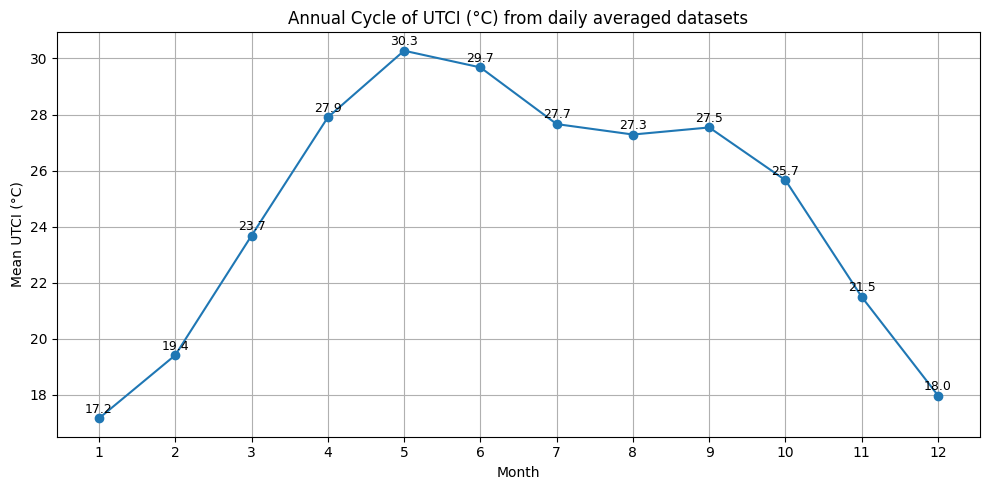

In [ ]:
plt.figure(figsize=(10, 5))
monthly_cycle.plot(marker='o')

for month, value in monthly_cycle.items():
    plt.text(month, value + 0.2, f"{value:.1f}", ha='center', fontsize=9)

plt.title("Annual Cycle of UTCI (°C) from daily averaged datasets")
plt.xlabel("Month")
plt.ylabel("Mean UTCI (°C)")
plt.grid(True)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


Bar chart of UTCI stress categories

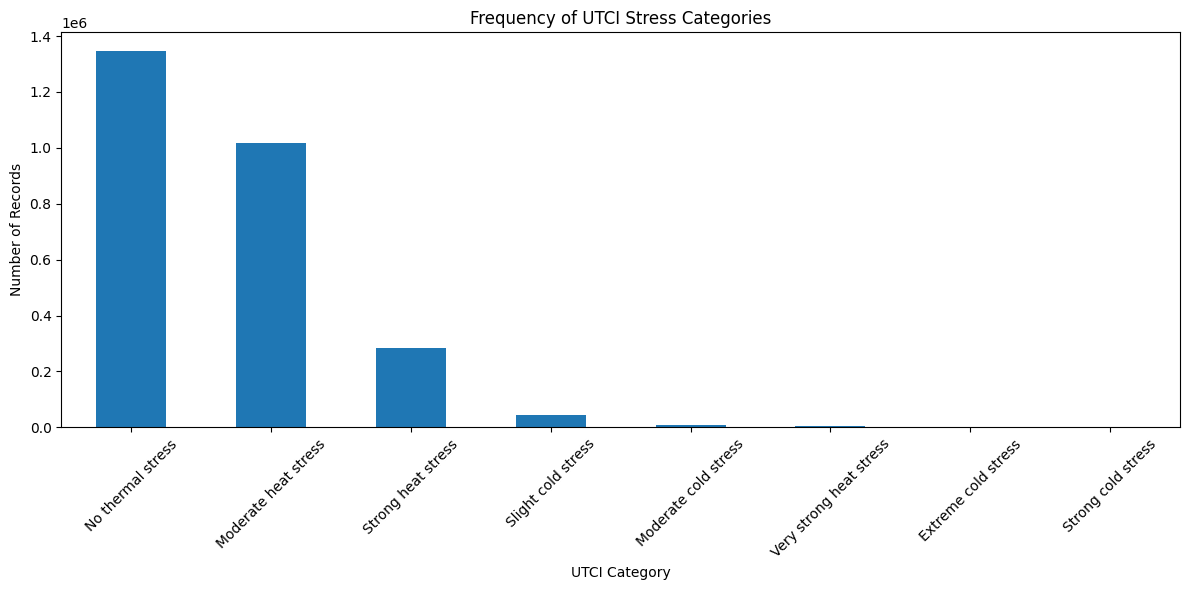

In [ ]:
category_counts = df['UTCI Category'].value_counts()

plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title("Frequency of UTCI Stress Categories")
plt.ylabel("Number of Records")
plt.xlabel("UTCI Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


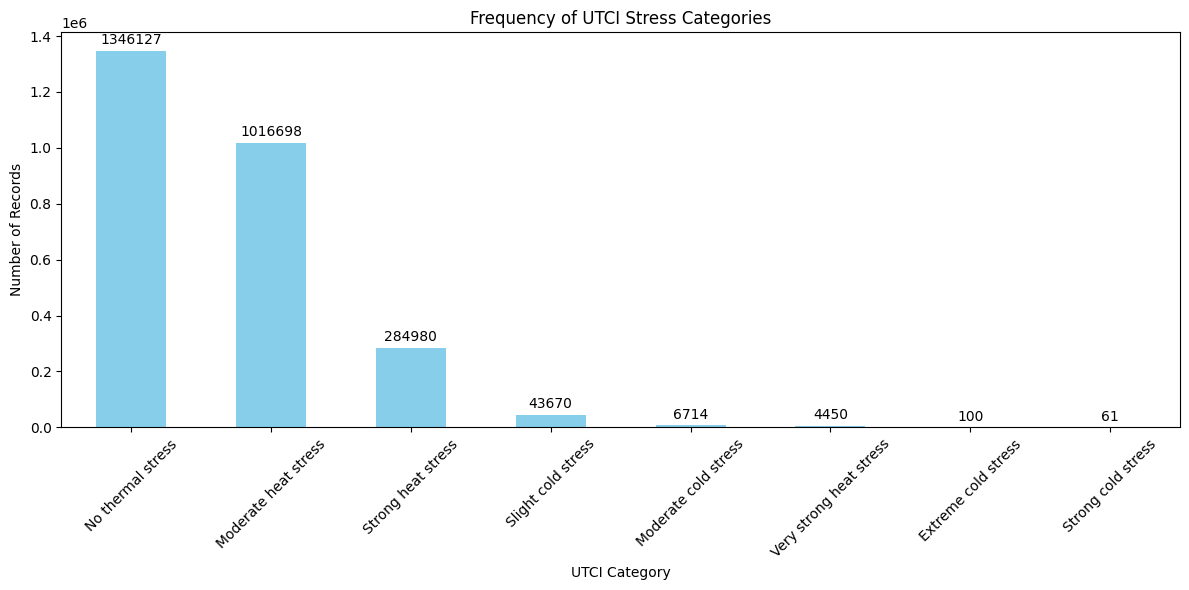

In [ ]:
import matplotlib.pyplot as plt

category_counts = df['UTCI Category'].value_counts()

plt.figure(figsize=(12, 6))
ax = category_counts.plot(kind='bar', color='skyblue')  # store axis object
plt.title("Frequency of UTCI Stress Categories")
plt.ylabel("Number of Records")
plt.xlabel("UTCI Category")
plt.xticks(rotation=45)
plt.tight_layout()

# Add value labels on top of bars
for i, value in enumerate(category_counts.values):
    ax.text(i, value + max(category_counts.values)*0.01, str(value),
            ha='center', va='bottom', fontsize=10)

plt.show()


Time series plot of UTCI per city

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure time is datetime
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month

monthly_cycle = df.groupby('month')['utci_celsius'].mean()

plt.figure(figsize=(10, 5))
monthly_cycle.plot(marker='o')
plt.title("Annual Cycle of UTCI (°C)")
plt.xlabel("Month")
plt.ylabel("Mean UTCI (°C)")
plt.grid(True)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("annual_cycle_utci.png")  # Save as image
plt.close()


In [ ]:
category_counts = df['UTCI Category'].value_counts()

plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')
plt.title("Frequency of UTCI Stress Categories")
plt.ylabel("Number of Records")
plt.xlabel("UTCI Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("utci_stress_categories_bar.png")
plt.close()


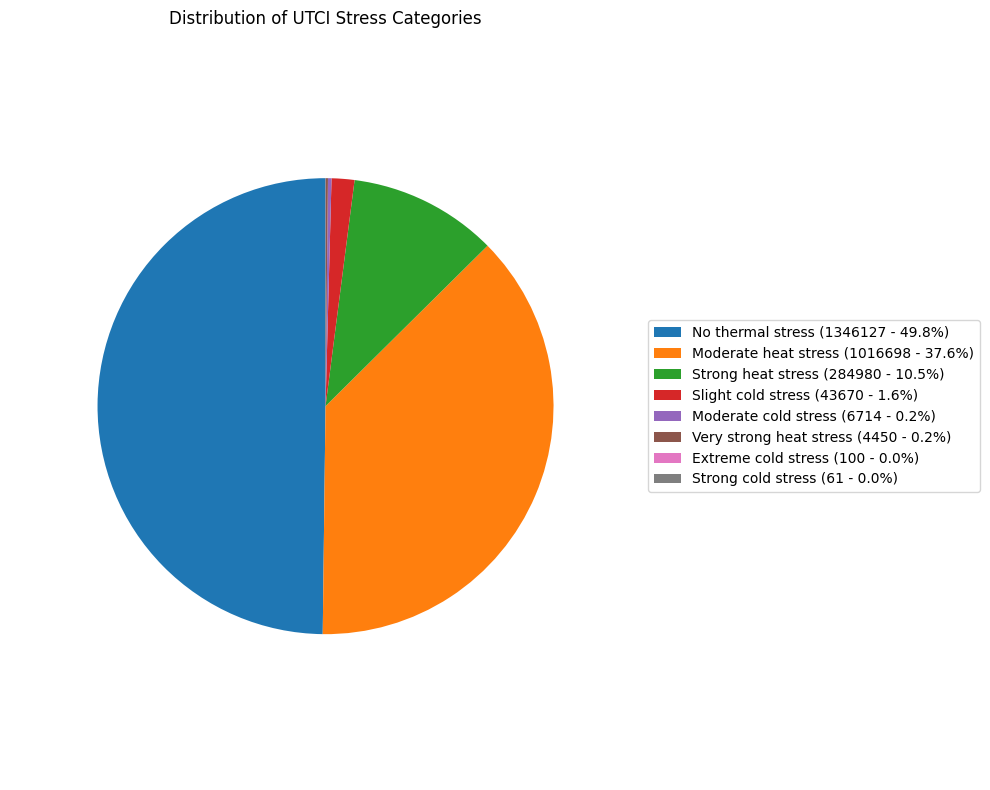

In [ ]:
import matplotlib.pyplot as plt

# Count the categories
category_counts = df['UTCI Category'].value_counts()

# Create labels with both count and %
labels = [f"{cat} ({val} - {val/len(df)*100:.1f}%)" for cat, val in category_counts.items()]

# Plot
plt.figure(figsize=(10, 8))
patches, texts = plt.pie(category_counts, startangle=90)

# Add legend instead of labels on the pie
plt.legend(patches, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Distribution of UTCI Stress Categories")
plt.axis('equal')  # Circular pie
plt.tight_layout()
plt.show()


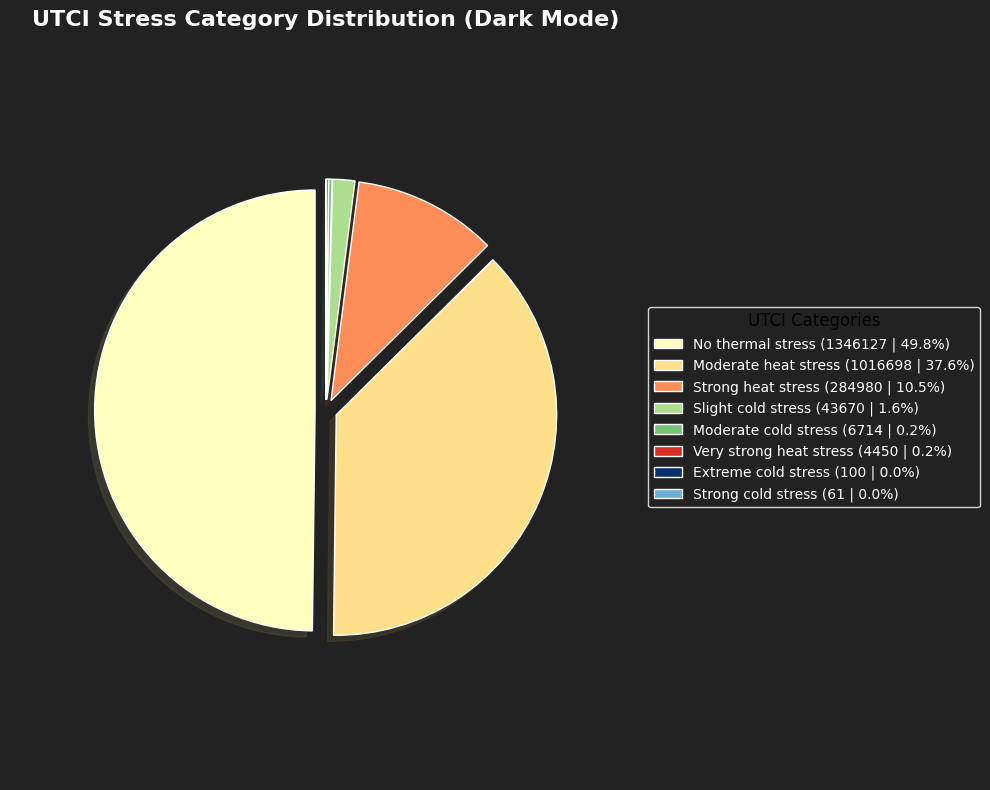

In [ ]:
import matplotlib.pyplot as plt

# Count categories
category_counts = df['UTCI Category'].value_counts()
total = category_counts.sum()

# Define gradient colors for stress severity
color_mapping = {
    "Extreme cold stress": "#08306B",       # dark blue
    "Very strong cold stress": "#2171B5",   # blue
    "Strong cold stress": "#6BAED6",        # light blue
    "Moderate cold stress": "#74C476",      # teal/greenish
    "Slight cold stress": "#ADDD8E",        # light green
    "No thermal stress": "#FFFFBF",         # yellow
    "Moderate heat stress": "#FEE08B",      # light orange
    "Strong heat stress": "#FC8D59",        # orange
    "Very strong heat stress": "#D73027",   # red-orange
    "Extreme heat stress": "#800026"        # dark red
}

colors = [color_mapping[cat] for cat in category_counts.index]
labels = [f"{cat} ({val} | {val/total*100:.1f}%)" for cat, val in category_counts.items()]
explode = [0.05]*len(category_counts)

# Create dark background figure
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#222222")
fig.patch.set_facecolor("#222222")
ax.set_facecolor("#222222")

# Plot pie
wedges, texts = ax.pie(
    category_counts,
    explode=explode,
    shadow=True,
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Legend outside with light text
ax.legend(
    wedges, labels,
    title="UTCI Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12,
    facecolor="#222222",
    edgecolor="white",
    labelcolor="white"
)

# Title in white
plt.title("UTCI Stress Category Distribution (Dark Mode)", fontsize=16, weight='bold', color="white")
plt.axis('equal')
plt.tight_layout()

# Save high-quality dark-mode images
plt.savefig("UTCI_stress_categories_darkmode.png", dpi=300, bbox_inches='tight', facecolor="#222222")
plt.savefig("UTCI_stress_categories_darkmode.pdf", dpi=300, bbox_inches='tight', facecolor="#222222")

plt.show()
